# Noise Parcel Simulation

Does a noise parcel help recover the true Vs when some voxels are noise?


To test this, I simualate data, where some voxels are pure noise (with different proportions of noise out of all voxels). I then fit models with and without a noise parcel, and with and without parcel-specific kappa. The true data comes from 10 real signal parcels and one noise parcel.

**4 models** all models have a total of 11 parcels:
1. MixVMF k = 11, single kappa
2. MixVMF k = 11, parcel-specific kappa
3. MixVMFNoise (k = 10 + 1 noise parcel), single kappa
4. MixVMFNoise (k = 10 + 1 noise parcel), parcel-specific kappa

In [77]:
import numpy as np
import torch as pt
import pandas as pd
import matplotlib.pyplot as plt
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.evaluation as ev
import HierarchBayesParcel.util as hut

In [78]:
# consts
K = 10 
P = 300
M = 15
n_subj = 5
n_part = 2
kappa_true = 15 # this is approx equal to the avg kappa across emissions for a cortical parcellation
rho_values = [0, 0.2, 0.3, 0.4, 0.5,0.6,0.7,0.9]
n_rep = 20  # repetitions per rho

part_vec = pt.kron(pt.arange(n_part), pt.ones(M,))
cond_vec = pt.kron(pt.ones(n_part,), pt.arange(M))
X = pt.tensor(hut.indicator(cond_vec), dtype=pt.float32)

In [ ]:
def generate_data(V_true, rho):
    """Generate data with K real parcels + rho fraction noise using MixVMFNoise.sample()."""
    K_total = K + 1
    arrange = ar.ArrangeIndependent(K_total, P, spatial_specific=True, remove_redundancy=False)
    logpi = pt.full((K_total, P), np.log((1 - rho) / K))
    logpi[K, :] = np.log(rho)
    if rho == 0:
        logpi = pt.full((K_total, P), np.log(1.0 / K))
        logpi[K, :] = -100 # if rho is 0, noise parcel should have 0 probability
    arrange.logpi = logpi
    U = arrange.sample(num_subj=n_subj)

    # MixVMFNoise.sample() — handles real parcels + noise voxels
    emission = em.MixVMFNoise(K=K_total, P=P, X=X, part_vec=part_vec)
    emission.V = V_true
    emission.kappa = pt.tensor(kappa_true, dtype=pt.float32)
    Y = emission.sample(U)
    return Y


def fit_model(Y, emission):
    K_fit = emission.K
    model = fm.FullMultiModel(ar.ArrangeIndependent(K_fit, P, spatial_specific=True, remove_redundancy=False),[emission])
    model.initialize([Y], subj_ind=[np.arange(n_subj)])
    model, ll, *_ = model.fit_em_ninits(iter=100, tol=0.01,
                                        fit_arrangement=True, fit_emission=True,
                                        init_arrangement=True, init_emission=True,
                                        n_inits=20, first_iter=15, verbose=False)
    return model


def v_recovery(V_fit, V_true):
    """Mean cosine similarity after greedy alignment"""
    K = V_fit.shape[1]
    idx = ev.matching_greedy(V_true[:, :K].T, V_fit[:, :K].T) # only matches top K parcels, ignored the least similar one which is likely the noise parcel
    V_aligned = V_fit[:, idx]
    V_aligned_norm = V_aligned / pt.sqrt((V_aligned ** 2).sum(dim=0))
    V_true_norm = V_true[:, :K] / pt.sqrt((V_true[:, :K] ** 2).sum(dim=0))
    cos = (V_aligned_norm * V_true_norm).sum(dim=0)
    return cos.mean().item()

In [87]:
# simulation
model_names = [
    'MixVMF (K = 11)',
    'MixVMF (K = 11, parcel kappa)',
    'MixVMFNoise (K = 10 + 1 noise)',
    'MixVMFNoise (K = 10 + 1 noise, parcel kappa)',
]


results = {name: {rho: [] for rho in rho_values} for name in model_names}
kappa_results = {name: {rho: [] for rho in rho_values} for name in model_names}

for rho in rho_values:
    print(f"Simulating for rho={rho}...")
    for rep in range(n_rep):
        V_true = pt.randn(M, K)
        V_true = V_true / pt.sqrt((V_true ** 2).sum(dim=0))

        Y = generate_data(V_true, rho)

        emissions = {
            'MixVMF (K = 11)': em.MixVMF(K=K+1, P=P, X=X, part_vec=part_vec),
            'MixVMF (K = 11, parcel kappa)': em.MixVMF(K=K+1, P=P, X=X, part_vec=part_vec, parcel_specific_kappa=True),
            'MixVMFNoise (K = 10 + 1 noise)': em.MixVMFNoise(K=K+1, P=P, X=X, part_vec=part_vec),
            'MixVMFNoise (K = 10 + 1 noise, parcel kappa)': em.MixVMFNoise(K=K+1, P=P, X=X, part_vec=part_vec,
                                                        parcel_specific_kappa=True),
        }

        for name, emission in emissions.items():
            m = fit_model(Y, emission)
            V_fit = m.emissions[0].V.detach()
            kappa_all = m.emissions[0].kappa.detach()
            if kappa_all.dim() == 0:
                kappa_per_parcel = [kappa_all.item()] * emission.K
            else:
                kappa_per_parcel = kappa_all.tolist()
            rec = v_recovery(V_fit, V_true)
            results[name][rho].append(rec)
            kappa_results[name][rho].append(kappa_per_parcel)

Simulating for rho=0...


C:\Users\barafat\AppData\Local\Temp\ipykernel_12176\2739228619.py:6: RuntimeWarning: divide by zero encountered in log
  logpi[K, :] = np.log(rho)
C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\emissions.py:346: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.part_vec = pt.tensor(part_vec, dtype=pt.int)


Likelihood decreased - terminating on iteration 7
Likelihood decreased - terminating on iteration 27
Likelihood decreased - terminating on iteration 9
Likelihood decreased - terminating on iteration 9
Likelihood decreased - terminating on iteration 18
Likelihood decreased - terminating on iteration 19
Likelihood decreased - terminating on iteration 8
Likelihood decreased - terminating on iteration 11
Likelihood decreased - terminating on iteration 14
Likelihood decreased - terminating on iteration 25
Likelihood decreased - terminating on iteration 7
Likelihood decreased - terminating on iteration 24
Likelihood decreased - terminating on iteration 11
Likelihood decreased - terminating on iteration 19
Likelihood decreased - terminating on iteration 26
Likelihood decreased - terminating on iteration 10
Likelihood decreased - terminating on iteration 5
Likelihood decreased - terminating on iteration 28
Likelihood decreased - terminating on iteration 15
Likelihood decreased - terminating on

In [ ]:
# rows = []
# for name in model_names:
#     for rho in rho_values:
#         for i, val in enumerate(results[name][rho]):
#             kappas = kappa_results[name][rho][i]
#             for k_idx, kval in enumerate(kappas):
#                 rows.append({
#                     'model': name,
#                     'rho': rho,
#                     'rep': i,
#                     'v_recovery': val,
#                     'parcel': k_idx,
#                     'kappa': kval,
#                 })
# df = pd.DataFrame(rows)
# df.to_csv('sim_vmfnoise.tsv', sep='\t', index=False)

In [89]:
df = pd.read_csv('sim_vmfnoise.tsv', sep='\t')

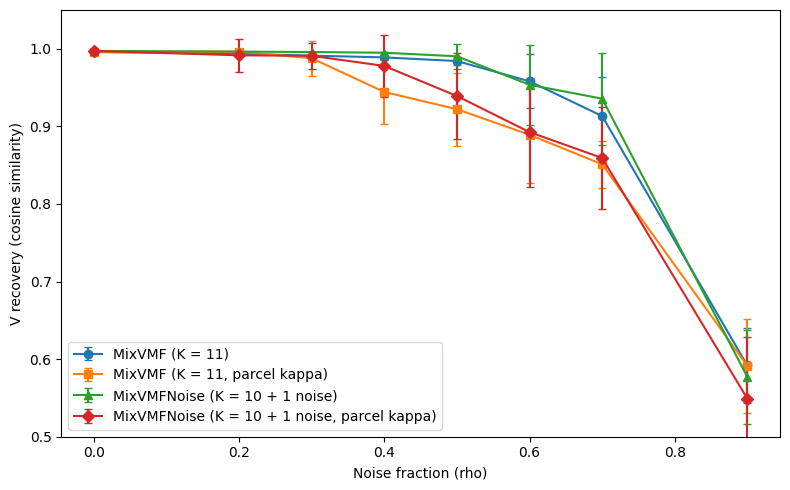

In [ ]:
markers = 'os^DvP*X'
fig, ax = plt.subplots(figsize=(8, 5))
for name, marker in zip(model_names, markers):
    dm = df[df.model == name]
    means = dm.groupby('rho').v_recovery.mean()
    std = dm.groupby('rho').v_recovery.std()
    ax.errorbar(means.index, means.values, yerr=std.values, marker=marker, label=name, capsize=3)
ax.set_xlabel('Noise fraction (rho)')
ax.set_ylabel('V recovery (cosine similarity)')
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


 conclusion: parcel specific kappa hurts V recovery when the true underlying parcels have a single kappa (plus a noise parcel with 0 kappa). Noise model doesnt really beat non noise for V recovery. The 11th parcel in the MixVMF model seems to absorb the noise well. In this analysis the V recovery does cos angle between true Vs (10 parcels) and the fitted Vs (for MixVMF models it would just be the 10 parcels most similar to the true Vs, for MixVMFnoise models there is only 10 fitted parcels)

C:\Users\barafat\AppData\Local\Temp\ipykernel_12176\2690582390.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rep['avg_kappa'] = df.groupby(['model', 'rho', 'rep'])['kappa'].mean().values


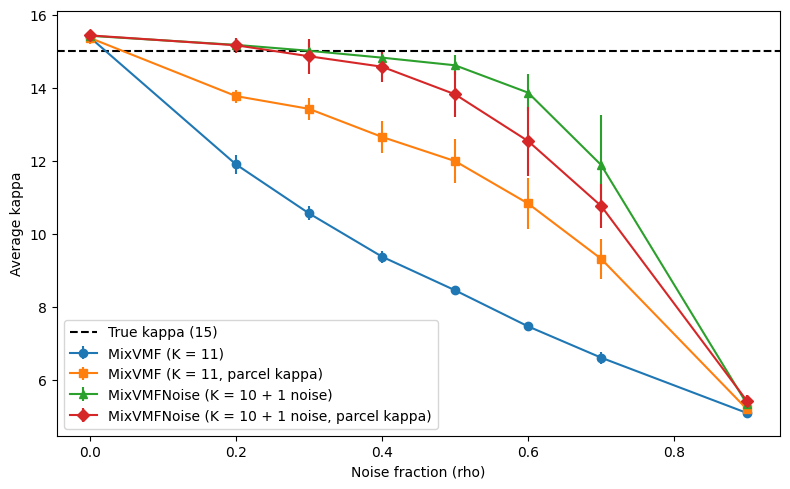

In [103]:
df_rep = df.drop_duplicates(subset=['model', 'rho', 'rep'])
df_rep['avg_kappa'] = df.groupby(['model', 'rho', 'rep'])['kappa'].mean().values

markers = 'os^DvP*X'
fig, ax = plt.subplots(figsize=(8, 5))
for name, marker in zip(model_names, markers):
    dm = df_rep[df_rep.model == name]
    means = dm.groupby('rho').avg_kappa.mean()
    std = dm.groupby('rho').avg_kappa.std()
    ax.errorbar(means.index, means.values, yerr=std.values, marker=marker, label=name)
ax.axhline(y=kappa_true, color='black', linestyle='--', label=f'True kappa ({kappa_true})')
ax.set_xlabel('Noise fraction (rho)')
ax.set_ylabel('Average kappa')
ax.legend()
plt.tight_layout()
plt.show()

the noise models seem to be better at kappa recovery than the non-noise. Here for the parcel specific kappa models, the kappa recovery is the mean across parcels of the fitted kappa values (for the MixVMFnoise model thats 10 parcels and for the MixVMF its 11). Single kappa models only have one kappa. Error bars are standard deviation across many repitions of the simulation.

the MixVMF (K = 11) model gets hit the hardest since nosie voxels contaminate global kappa. the mixVMF (K = 11, parcel kappa) contains the damage in one parcel but because there is a low kappa parcel it will compete for boundary voxels soemtimes taking voxels from actual parcels hurting v recovery. The noise model avoids both problems  by giving noise its own parcel.

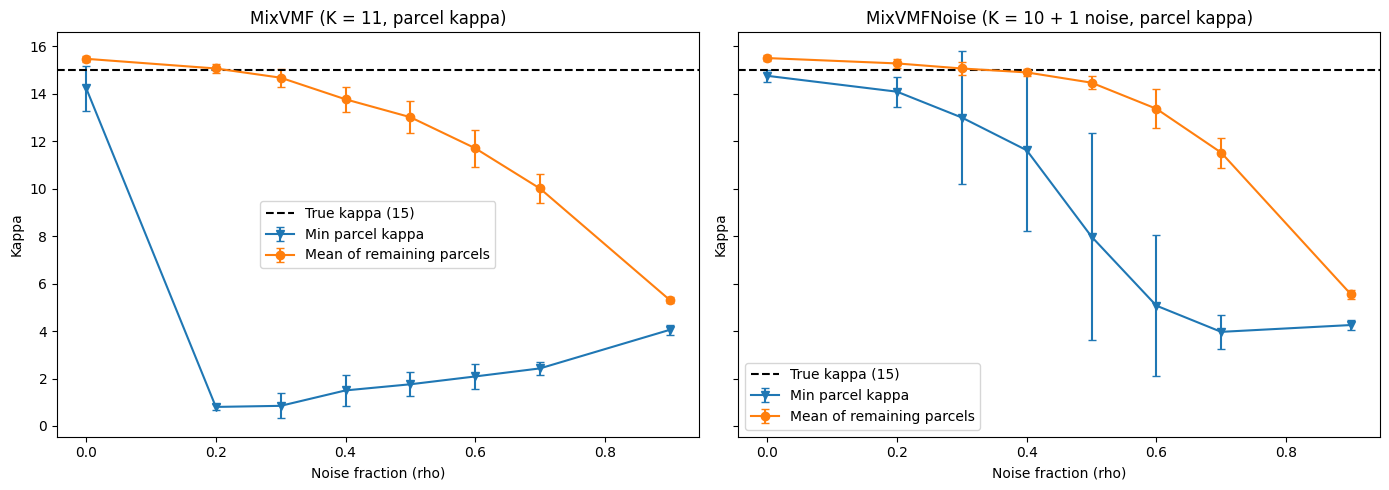

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
parcel_models = [n for n in model_names if 'parcel kappa' in n]

for ax, name in zip(axes, parcel_models):
    min_kappas = {rho: [] for rho in rho_values}
    rest_kappas = {rho: [] for rho in rho_values}
    for rho in rho_values:
        for rep_kappas in kappa_results[name][rho]:
            sorted_k = sorted(rep_kappas)
            min_kappas[rho].append(sorted_k[0])
            rest_kappas[rho].append(np.mean(sorted_k[1:]))
    
    rhos = list(rho_values)
    ax.errorbar(rhos, [np.mean(min_kappas[r]) for r in rhos],
                yerr=[np.std(min_kappas[r]) for r in rhos],
                marker='v', label='Min parcel kappa', capsize=3)
    ax.errorbar(rhos, [np.mean(rest_kappas[r]) for r in rhos],
                yerr=[np.std(rest_kappas[r]) for r in rhos],
                marker='o', label='Mean of remaining parcels', capsize=3)
    ax.axhline(y=kappa_true, color='black', linestyle='--', label=f'True kappa ({kappa_true})')
    ax.set_xlabel('Noise fraction (rho)')
    ax.set_ylabel('Kappa')
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

the noise model expplicitly gives a parcel to noise so at rho =0.2 right panel for example all fitted parcels are good and match the true kappa (including the min parcel). But on the left panel without noise parcel, the modeal assigns one of the 11 parcels to absorb noise, its kappa drops close to 0. 